<a href="https://colab.research.google.com/github/jerinSabrina/ASL_exercise/blob/main/Data_Mining_Cup_Course/DMC_rf_timeseries_h128_2nd_version_sabrina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Random Forest Time-Series Model — h=128 Working Rows

This notebook builds
1. engineered features
2. trains Random Forest
3. runs time-series CV/random search,
4. validates, tests, and saves SMAPE outputs.

#####Import library

In [179]:

import os
import math
import warnings
from datetime import date, timedelta

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import make_scorer
from scipy.stats import randint


#####Load Data

In [180]:
input_path = "/content/sample_data/eingangsbandwaage_studenten (1).csv"
fraction_path = "/content/sample_data/ballengewichte_studenten (2).csv"

input_df = pd.read_csv(input_path)
fraction_df = pd.read_csv(fraction_path)

print("Input mass shape:", input_df.shape)
print("Fraction shape:", fraction_df.shape)

print("\nInput columns:")
print(input_df.columns.tolist())

print("\nFraction columns:")
print(fraction_df.columns.tolist())

Input mass shape: (1896, 2)
Fraction shape: (1546, 14)

Input columns:
['Zeitstempel', 'Masse']

Fraction columns:
['Datum', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13']


######Standardize date columns and merge

In [181]:
# Convert date columns
input_df["Zeitstempel"] = pd.to_datetime(input_df["Zeitstempel"])
fraction_df["Datum"] = pd.to_datetime(fraction_df["Datum"])

# Rename input date column so both files use the same date column
input_df = input_df.rename(columns={"Zeitstempel": "Datum"})

# Define fraction columns
fraction_cols = [str(i) for i in range(1, 15)]

# Merge: keep only dates where fraction data exists
df = fraction_df.merge(input_df, on="Datum", how="left")

# Sort chronologically
df = df.sort_values("Datum").reset_index(drop=True)

print("Merged shape:", df.shape)
print("Date range:", df["Datum"].min(), "to", df["Datum"].max())

display(df.head())

Merged shape: (1546, 15)
Date range: 2020-03-02 00:00:00 to 2024-12-31 00:00:00


,Datum,1,2,3,4,5,6,7,8,9,10,11,12,13,Masse
0,2020-03-02,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.291561
1,2020-03-12,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.638127
2,2020-03-18,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.320958
3,2020-03-19,0.174107,0.162197,0.045873,0.143295,0.094573,0.030079,0.058928,0.080483,0.196569,0.013896,0.000000,0.0,0.00000,0.457763
4,2020-03-20,0.215771,0.207817,0.049766,0.105373,0.072167,0.016228,0.060927,0.059821,0.117118,0.000000,0.006941,0.0,0.08807,0.544210


In [182]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1546
Columns: 15


#####Add NRW public holiday features

This step adds holiday-related calendar features to the dataset.

NRW public holidays are useful because material input and fraction behavior

may change before, during, or after holidays.

In [183]:
import holidays

years = range(df["Datum"].dt.year.min(), df["Datum"].dt.year.max() + 1)

# NRW = North Rhine-Westphalia, subdivision code "NW"
nrw_holidays = holidays.country_holidays(
    country="DE",
    subdiv="NW",
    years=years
)

df["date_only"] = df["Datum"].dt.date

# Main holiday indicator column
df["is_holiday"] = df["date_only"].isin(nrw_holidays).astype(int)

# More specific name, useful for report clarity
df["is_public_holiday_NRW"] = df["is_holiday"]

# Holiday name
df["holiday_name"] = df["date_only"].map(
    lambda x: nrw_holidays.get(x, "")
)

# Day before and after public holiday
holiday_dates = set(nrw_holidays.keys())

df["is_day_before_holiday"] = df["date_only"].map(
    lambda x: int((pd.Timestamp(x) + pd.Timedelta(days=1)).date() in holiday_dates)
)

df["is_day_after_holiday"] = df["date_only"].map(
    lambda x: int((pd.Timestamp(x) - pd.Timedelta(days=1)).date() in holiday_dates)
)

# Correct fraction_cols to match the actual columns in df
# The original fraction_cols was likely defined to include '14', but the loaded data
# only contains fraction columns '1' through '13'.
fraction_cols = [col for col in df.columns if col.isdigit()]

# Table of all holiday rows before weekend removal
holiday_table_all = df[df["is_holiday"] == 1][
    ["Datum", "holiday_name", "is_holiday", "Masse"] + fraction_cols
].copy()

print("All NRW public holiday rows in fraction dataset:")
display(holiday_table_all)

print("\nHoliday count before weekend removal:", df["is_holiday"].sum())
print("Day-before-holiday count:", df["is_day_before_holiday"].sum())
print("Day-after-holiday count:", df["is_day_after_holiday"].sum())

All NRW public holiday rows in fraction dataset:


,Datum,holiday_name,is_holiday,Masse,1,2,3,4,5,6,7,8,9,10,11,12,13
25,2020-04-10,Good Friday,1,0.185060,0.082660,0.094556,0.142390,0.127620,0.169328,0.074415,0.034470,0.069988,0.053435,0.062771,0.088367,0.000000,0.000000
26,2020-04-13,Easter Monday,1,0.483262,0.148694,0.064995,0.165111,0.058163,0.157998,0.045207,0.022223,0.056304,0.054422,0.102027,0.124855,0.000000,0.000000
44,2020-05-01,Labor Day,1,0.645800,0.172599,0.065813,0.092910,0.055521,0.132217,0.050777,0.021390,0.066014,0.058963,0.175142,0.103678,0.004975,0.000000
64,2020-05-21,Ascension Day,1,0.449232,0.193624,0.060991,0.119256,0.039545,0.140358,0.046393,0.021188,0.049101,0.046958,0.164839,0.108773,0.008973,0.000000
74,2020-06-01,Whit Monday,1,0.503815,0.188259,0.050775,0.130410,0.062297,0.154397,0.027240,0.020895,0.058489,0.057182,0.197237,0.052818,0.000000,0.000000
80,2020-06-11,Corpus Christi,1,0.702709,0.252611,0.069585,0.080130,0.047750,0.127482,0.031643,0.018895,0.066424,0.039492,0.154900,0.102690,0.008398,0.000000
180,2020-10-03,German Unity Day,1,0.168750,0.198078,0.091847,0.073825,0.045696,0.111476,0.064202,0.053357,0.039997,0.080889,0.115640,0.084669,0.040323,0.000000
198,2020-11-01,All Saints' Day,1,0.052009,0.000000,0.200546,0.000000,0.000000,0.120842,0.000000,0.000000,0.086614,0.000000,0.468745,0.123252,0.000000,0.000000
255,2021-01-01,New Year's Day,1,0.048531,0.123885,0.082641,0.170792,0.064212,0.249748,0.031815,0.000000,0.104175,0.068868,0.042174,0.061690,0.000000,0.000000
345,2021-04-02,Good Friday,1,0.215725,0.227650,0.060233,0.110930,0.077584,0.105859,0.040203,0.006889,0.033266,0.039661,0.190987,0.106736,0.000000,0.000000



Holiday count before weekend removal: 36
Day-before-holiday count: 34
Day-after-holiday count: 46


#####Exclude weekends, keep holidays, and clean negative Masse

In [184]:

# Add weekday information before filtering
df["weekday"] = df["Datum"].dt.day_name()
df["weekday_num"] = df["Datum"].dt.dayofweek

# Exclude only Saturday and Sunday
# Important: public holidays on weekdays are kept in the dataset.
work_df = df[df["weekday_num"] < 5].copy().reset_index(drop=True)

# Negative mass is physically impossible, so clip to 0 for modelling
work_df["Masse_original"] = work_df["Masse"]
work_df["Masse"] = work_df["Masse"].clip(lower=0)

print("Shape after weekend removal:", work_df.shape)
print("Date range after weekend removal:", work_df["Datum"].min(), "to", work_df["Datum"].max())

print("\nWeekday counts after weekend removal:")
display(work_df["weekday"].value_counts().sort_index())

# Table of all holidays that remain after weekend removal
holiday_table_workdays = work_df[work_df["is_holiday"] == 1][
    ["Datum", "weekday", "holiday_name", "is_holiday", "Masse"]
].copy()

print("\nNRW public holidays kept after weekend removal:")
display(holiday_table_workdays)

print("\nNumber of weekday public holidays kept:", len(holiday_table_workdays))

print("\nFinal working dataset preview:")
display(work_df.tail())

Shape after weekend removal: (1202, 24)
Date range after weekend removal: 2020-03-02 00:00:00 to 2024-12-31 00:00:00

Weekday counts after weekend removal:


,count
weekday,
Friday,243
Monday,232
Thursday,244
Tuesday,240
Wednesday,243



NRW public holidays kept after weekend removal:


,Datum,weekday,holiday_name,is_holiday,Masse
19,2020-04-10,Friday,Good Friday,1,0.185060
20,2020-04-13,Monday,Easter Monday,1,0.483262
34,2020-05-01,Friday,Labor Day,1,0.645800
48,2020-05-21,Thursday,Ascension Day,1,0.449232
55,2020-06-01,Monday,Whit Monday,1,0.503815
61,2020-06-11,Thursday,Corpus Christi,1,0.702709
198,2021-01-01,Friday,New Year's Day,1,0.048531
263,2021-04-02,Friday,Good Friday,1,0.215725
264,2021-04-05,Monday,Easter Monday,1,0.016547
292,2021-05-13,Thursday,Ascension Day,1,0.722911



Number of weekday public holidays kept: 32

Final working dataset preview:


,Datum,1,2,3,4,5,6,7,8,9,...,Masse,date_only,is_holiday,is_public_holiday_NRW,holiday_name,is_day_before_holiday,is_day_after_holiday,weekday,weekday_num,Masse_original
1197,2024-12-24,0.221623,0.142965,0.127144,0.072535,0.109840,0.048001,0.015443,0.059910,0.047961,...,0.820967,2024-12-24,0,0,,1,0,Tuesday,1,0.820967
1198,2024-12-26,0.227366,0.151756,0.000000,0.000000,0.184199,0.058182,0.000000,0.074716,0.091876,...,0.747486,2024-12-26,1,1,Second Day of Christmas,0,1,Thursday,3,0.747486
1199,2024-12-27,0.263026,0.131817,0.123569,0.068892,0.114085,0.050643,0.010281,0.046770,0.060500,...,0.893760,2024-12-27,0,0,,0,1,Friday,4,0.893760
1200,2024-12-30,0.246167,0.136020,0.110706,0.071743,0.107153,0.043589,0.010769,0.044998,0.053787,...,0.862853,2024-12-30,0,0,,0,0,Monday,0,0.862853
1201,2024-12-31,0.258223,0.101629,0.108412,0.056203,0.112360,0.070415,0.010237,0.047472,0.054964,...,0.796738,2024-12-31,0,0,,0,0,Tuesday,1,0.796738


#####Model configuration

In [185]:
HORIZON = 128                      # 128 working rows ahead
SEASONAL_PERIOD = 252             # approx. one working year
N_SPLITS_CV = 5
RANDOM_STATE = 42                 #makes the Random Forest results reproducible
LAGS = [1, 2, 5, 10, 21, 63, 126] #short-term memory: 1, 2, 5, 10(current fraction depends on last week)  # medium-term memory: 21, 63(last month) # longer-term memory: 126(previous quarter)
ROLLING_WINDOWS = [5, 10, 21, 63] #Rolling features can capture: recent average,recent volatility,recent minimum,recent maximum,recent trend
fraction_cols = [str(i) for i in range(1, 14)]
FRACTION_COLS = fraction_cols
MASS_COL = "Masse"
DATE_COL = "Datum"
# Use fewer iterations to keep runtime reasonable, but still do real tuning.
N_RANDOM_SEARCH_ITER = 4

######Define Function ( SMAPE_NP , SMAPE_per_function, Smape_scorer_func, Postprocess_fraction_prediction )

In [186]:
def smape_np(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred) + eps
    smape = 2.0 * np.abs(y_pred - y_true) / denom

    return np.mean(smape)


def smape_per_fraction_df(y_true, y_pred, fraction_cols=FRACTION_COLS):
    rows = []
    for i, col in enumerate(fraction_cols):
        rows.append({
            "fraction": col,
            "SMAPE": smape_np(y_true[:, i], y_pred[:, i])
        })
    return pd.DataFrame(rows)


def smape_scorer_func(y_true, y_pred):
    return -smape_np(y_true, y_pred)

SMAPE_SCORER = make_scorer(smape_scorer_func, greater_is_better=True)


def postprocess_fraction_predictions(pred):
    """Clip predictions to [0, 1] and normalize rows to sum to 1 when possible."""
    pred = np.asarray(pred, dtype=float)
    pred = np.clip(pred, 0.0, 1.0)
    row_sum = pred.sum(axis=1, keepdims=True)
    out = pred.copy()
    valid = row_sum[:, 0] > 0
    out[valid] = out[valid] / row_sum[valid]
    return out


####Feature Engineering

#####FEATURE GROUP 1: ORIGIN CALENDAR FEATURES

In [187]:
# =========================================================
# FEATURE GROUP 1: ORIGIN CALENDAR FEATURES
# =========================================================
#At this date, what month is it?
#Which working day is it?
#Which week of the year?
#Which quarter?
#Where is it in the yearly cycle?


# Origin date = current date where we create the prediction
work_df["origin_year"] = work_df["Datum"].dt.year
work_df["origin_month"] = work_df["Datum"].dt.month
work_df["origin_dayofweek"] = work_df["Datum"].dt.dayofweek
work_df["origin_dayofyear"] = work_df["Datum"].dt.dayofyear
work_df["origin_weekofyear"] = work_df["Datum"].dt.isocalendar().week.astype(int)
work_df["origin_quarter"] = work_df["Datum"].dt.quarter

origin_calendar_features = [
    "origin_year",
    "origin_month",
    "origin_dayofweek",
    "origin_dayofyear",
    "origin_weekofyear",
    "origin_quarter",
]

print("Origin calendar features added:")
print(origin_calendar_features)
print("shape", work_df.shape)

display(work_df.tail())


Origin calendar features added:
['origin_year', 'origin_month', 'origin_dayofweek', 'origin_dayofyear', 'origin_weekofyear', 'origin_quarter']
shape (1202, 30)


,Datum,1,2,3,4,5,6,7,8,9,...,is_day_after_holiday,weekday,weekday_num,Masse_original,origin_year,origin_month,origin_dayofweek,origin_dayofyear,origin_weekofyear,origin_quarter
1197,2024-12-24,0.221623,0.142965,0.127144,0.072535,0.109840,0.048001,0.015443,0.059910,0.047961,...,0,Tuesday,1,0.820967,2024,12,1,359,52,4
1198,2024-12-26,0.227366,0.151756,0.000000,0.000000,0.184199,0.058182,0.000000,0.074716,0.091876,...,1,Thursday,3,0.747486,2024,12,3,361,52,4
1199,2024-12-27,0.263026,0.131817,0.123569,0.068892,0.114085,0.050643,0.010281,0.046770,0.060500,...,1,Friday,4,0.893760,2024,12,4,362,52,4
1200,2024-12-30,0.246167,0.136020,0.110706,0.071743,0.107153,0.043589,0.010769,0.044998,0.053787,...,0,Monday,0,0.862853,2024,12,0,365,1,4
1201,2024-12-31,0.258223,0.101629,0.108412,0.056203,0.112360,0.070415,0.010237,0.047472,0.054964,...,0,Tuesday,1,0.796738,2024,12,1,366,1,4


In [188]:
# =========================================================
# FEATURE GROUP 1B: ORIGIN FOURIER FEATURES
# =========================================================
# Fourier features convert cyclic calendar positions into sine/cosine waves.
# We create yearly working-day Fourier and month-of-year Fourier separately.

origin_fourier_features = []

work_df["origin_workday_of_year"] = ( work_df.groupby("origin_year").cumcount() + 1 )
# ---------------------------------------------------------
# 1. Yearly working-day Fourier
# ---------------------------------------------------------
# Because weekends are removed, we use origin_workday_of_year with period 252.
# Do NOT use origin_dayofyear / 252.

yearly_fourier_orders = [1, 2, 3]
yearly_period = 252

for k in yearly_fourier_orders:
    sin_col = f"origin_workyear_sin_k{k}"
    cos_col = f"origin_workyear_cos_k{k}"

    angle = 2 * np.pi * k * work_df["origin_workday_of_year"] / yearly_period

    work_df[sin_col] = np.sin(angle)
    work_df[cos_col] = np.cos(angle)

    origin_fourier_features.extend([sin_col, cos_col])


# ---------------------------------------------------------
# 2. Month-of-year Fourier
# ---------------------------------------------------------
# This captures January, February, ..., December as a yearly monthly cycle.

monthly_fourier_orders = [1, 2]
monthly_period = 12

for k in monthly_fourier_orders:
    sin_col = f"origin_month_sin_k{k}"
    cos_col = f"origin_month_cos_k{k}"

    angle = 2 * np.pi * k * work_df["origin_month"] / monthly_period

    work_df[sin_col] = np.sin(angle)
    work_df[cos_col] = np.cos(angle)

    origin_fourier_features.extend([sin_col, cos_col])


print("Origin Fourier features added:")
print(origin_fourier_features)
print("shape", work_df.shape)

display(
    work_df[
        ["Datum", "origin_month", "origin_workday_of_year"]
        + origin_fourier_features
    ].head()
)


Origin Fourier features added:
['origin_workyear_sin_k1', 'origin_workyear_cos_k1', 'origin_workyear_sin_k2', 'origin_workyear_cos_k2', 'origin_workyear_sin_k3', 'origin_workyear_cos_k3', 'origin_month_sin_k1', 'origin_month_cos_k1', 'origin_month_sin_k2', 'origin_month_cos_k2']
shape (1202, 41)


,Datum,origin_month,origin_workday_of_year,origin_workyear_sin_k1,origin_workyear_cos_k1,origin_workyear_sin_k2,origin_workyear_cos_k2,origin_workyear_sin_k3,origin_workyear_cos_k3,origin_month_sin_k1,origin_month_cos_k1,origin_month_sin_k2,origin_month_cos_k2
0,2020-03-02,3,1,0.024931,0.999689,0.049846,0.998757,0.074730,0.997204,1.0,6.123234e-17,1.224647e-16,-1.0
1,2020-03-12,3,2,0.049846,0.998757,0.099568,0.995031,0.149042,0.988831,1.0,6.123234e-17,1.224647e-16,-1.0
2,2020-03-18,3,3,0.074730,0.997204,0.149042,0.988831,0.222521,0.974928,1.0,6.123234e-17,1.224647e-16,-1.0
3,2020-03-19,3,4,0.099568,0.995031,0.198146,0.980172,0.294755,0.955573,1.0,6.123234e-17,1.224647e-16,-1.0
4,2020-03-20,3,5,0.124344,0.992239,0.246757,0.969077,0.365341,0.930874,1.0,6.123234e-17,1.224647e-16,-1.0


#####FEATURE GROUP 2: TARGET DATE + TARGET CALENDAR FEATURES

In [189]:
# =========================================================
# FEATURE GROUP 2: TARGET DATE + TARGET CALENDAR FEATURES
# =========================================================

# Target date is h working rows ahead
# Because weekends were removed, shift(-10) means 10 working rows ahead
work_df["target_date"] = work_df["Datum"].shift(-HORIZON)

# Calendar features of the target date
# These are known in advance, so they are safe to use as features
work_df["target_month"] = work_df["target_date"].dt.month
work_df["target_dayofweek"] = work_df["target_date"].dt.dayofweek
work_df["target_dayofyear"] = work_df["target_date"].dt.dayofyear
work_df["target_weekofyear"] = work_df["target_date"].dt.isocalendar().week.astype("Int64")
work_df["target_quarter"] = work_df["target_date"].dt.quarter


target_calendar_features = [
    "target_month",
    "target_dayofweek",
    "target_dayofyear",
    "target_weekofyear",
    "target_quarter"
]

print("Target calendar features added:")
print(target_calendar_features)
print("shape", work_df.shape)
display(work_df.head(15))

Target calendar features added:
['target_month', 'target_dayofweek', 'target_dayofyear', 'target_weekofyear', 'target_quarter']
shape (1202, 47)


,Datum,1,2,3,4,5,6,7,8,9,...,origin_month_sin_k1,origin_month_cos_k1,origin_month_sin_k2,origin_month_cos_k2,target_date,target_month,target_dayofweek,target_dayofyear,target_weekofyear,target_quarter
0,2020-03-02,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,6.123234e-17,1.224647e-16,-1.0,2020-09-15,9.0,1.0,259.0,38,3.0
1,2020-03-12,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,6.123234e-17,1.224647e-16,-1.0,2020-09-16,9.0,2.0,260.0,38,3.0
2,2020-03-18,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,6.123234e-17,1.224647e-16,-1.0,2020-09-17,9.0,3.0,261.0,38,3.0
3,2020-03-19,0.174107,0.162197,0.045873,0.143295,0.094573,0.030079,0.058928,0.080483,0.196569,...,1.000000,6.123234e-17,1.224647e-16,-1.0,2020-09-18,9.0,4.0,262.0,38,3.0
4,2020-03-20,0.215771,0.207817,0.049766,0.105373,0.072167,0.016228,0.060927,0.059821,0.117118,...,1.000000,6.123234e-17,1.224647e-16,-1.0,2020-09-21,9.0,0.0,265.0,39,3.0
5,2020-03-23,0.205198,0.149809,0.036214,0.104664,0.102665,0.029861,0.027363,0.062071,0.102814,...,1.000000,6.123234e-17,1.224647e-16,-1.0,2020-09-22,9.0,1.0,266.0,39,3.0
6,2020-03-24,0.185218,0.116990,0.097024,0.068136,0.079592,0.033660,0.010828,0.045293,0.063684,...,1.000000,6.123234e-17,1.224647e-16,-1.0,2020-09-23,9.0,2.0,267.0,39,3.0
7,2020-03-25,0.203316,0.083606,0.143635,0.093358,0.141571,0.050733,0.021842,0.064978,0.047957,...,1.000000,6.123234e-17,1.224647e-16,-1.0,2020-09-24,9.0,3.0,268.0,39,3.0
8,2020-03-26,0.219463,0.099465,0.073657,0.067584,0.103432,0.044236,0.018350,0.064958,0.061046,...,1.000000,6.123234e-17,1.224647e-16,-1.0,2020-09-25,9.0,4.0,269.0,39,3.0
9,2020-03-27,0.176155,0.103812,0.100679,0.075952,0.126853,0.062327,0.020537,0.074794,0.062950,...,1.000000,6.123234e-17,1.224647e-16,-1.0,2020-09-28,9.0,0.0,272.0,40,3.0


In [190]:
# =========================================================
# FEATURE GROUP 2B: TARGET FOURIER FEATURES
# =========================================================
# Fourier features convert cyclic target-date positions into sine/cosine waves.
# Here we add:
# 1. yearly working-day Fourier using period = 252
# 2. month-of-year Fourier using period = 12

target_fourier_features = []


# ---------------------------------------------------------
# Target working-day number inside the year
# ---------------------------------------------------------
# This maps each target_date to its working-day position in that year.
# Example: first working day of the year = 1, second = 2, etc.

# Make sure origin_workday_of_year already exists

if "origin_workday_of_year" not in work_df.columns:
    work_df["origin_workday_of_year"] = (
        work_df.groupby("origin_year").cumcount() + 1
    )

workday_lookup = work_df.set_index("Datum")["origin_workday_of_year"]

work_df["target_workday_of_year"] = (
    work_df["target_date"]
    .map(workday_lookup)
    .astype("Int64")
)
# ---------------------------------------------------------
# 1. Target yearly working-day Fourier
# ---------------------------------------------------------
# Correct because weekends are removed.
# Do NOT use target_dayofyear / 252.

target_yearly_fourier_orders = [1, 2, 3]
target_yearly_period = 252

target_workday_float = work_df["target_workday_of_year"].astype(float)

for k in target_yearly_fourier_orders:
    sin_col = f"target_workyear_sin_k{k}"
    cos_col = f"target_workyear_cos_k{k}"

    angle = 2 * np.pi * k * target_workday_float / target_yearly_period

    work_df[sin_col] = np.sin(angle)
    work_df[cos_col] = np.cos(angle)

    target_fourier_features.extend([sin_col, cos_col])


# ---------------------------------------------------------
# 2. Target month-of-year Fourier
# ---------------------------------------------------------
# This captures January, February, ..., December as a yearly monthly cycle.

target_monthly_fourier_orders = [1, 2]
target_monthly_period = 12

target_month_float = work_df["target_month"].astype(float)

for k in target_monthly_fourier_orders:
    sin_col = f"target_month_sin_k{k}"
    cos_col = f"target_month_cos_k{k}"

    angle = 2 * np.pi * k * target_month_float / target_monthly_period

    work_df[sin_col] = np.sin(angle)
    work_df[cos_col] = np.cos(angle)

    target_fourier_features.extend([sin_col, cos_col])


print("Target Fourier features added:")
print(target_fourier_features)
print("shape", work_df.shape)

display(
    work_df[
        ["Datum", "target_date", "target_month", "target_workday_of_year"]
        + target_fourier_features
    ].head(15)
)

Target Fourier features added:
['target_workyear_sin_k1', 'target_workyear_cos_k1', 'target_workyear_sin_k2', 'target_workyear_cos_k2', 'target_workyear_sin_k3', 'target_workyear_cos_k3', 'target_month_sin_k1', 'target_month_cos_k1', 'target_month_sin_k2', 'target_month_cos_k2']
shape (1202, 58)


,Datum,target_date,target_month,target_workday_of_year,target_workyear_sin_k1,target_workyear_cos_k1,target_workyear_sin_k2,target_workyear_cos_k2,target_workyear_sin_k3,target_workyear_cos_k3,target_month_sin_k1,target_month_cos_k1,target_month_sin_k2,target_month_cos_k2
0,2020-03-02,2020-09-15,9.0,129,-0.074730,-0.997204,0.149042,0.988831,-0.222521,-0.974928,-1.000000,-1.836970e-16,3.673940e-16,-1.0
1,2020-03-12,2020-09-16,9.0,130,-0.099568,-0.995031,0.198146,0.980172,-0.294755,-0.955573,-1.000000,-1.836970e-16,3.673940e-16,-1.0
2,2020-03-18,2020-09-17,9.0,131,-0.124344,-0.992239,0.246757,0.969077,-0.365341,-0.930874,-1.000000,-1.836970e-16,3.673940e-16,-1.0
3,2020-03-19,2020-09-18,9.0,132,-0.149042,-0.988831,0.294755,0.955573,-0.433884,-0.900969,-1.000000,-1.836970e-16,3.673940e-16,-1.0
4,2020-03-20,2020-09-21,9.0,133,-0.173648,-0.984808,0.342020,0.939693,-0.500000,-0.866025,-1.000000,-1.836970e-16,3.673940e-16,-1.0
5,2020-03-23,2020-09-22,9.0,134,-0.198146,-0.980172,0.388435,0.921476,-0.563320,-0.826239,-1.000000,-1.836970e-16,3.673940e-16,-1.0
6,2020-03-24,2020-09-23,9.0,135,-0.222521,-0.974928,0.433884,0.900969,-0.623490,-0.781831,-1.000000,-1.836970e-16,3.673940e-16,-1.0
7,2020-03-25,2020-09-24,9.0,136,-0.246757,-0.969077,0.478254,0.878222,-0.680173,-0.733052,-1.000000,-1.836970e-16,3.673940e-16,-1.0
8,2020-03-26,2020-09-25,9.0,137,-0.270840,-0.962624,0.521435,0.853291,-0.733052,-0.680173,-1.000000,-1.836970e-16,3.673940e-16,-1.0
9,2020-03-27,2020-09-28,9.0,138,-0.294755,-0.955573,0.563320,0.826239,-0.781831,-0.623490,-1.000000,-1.836970e-16,3.673940e-16,-1.0


In [191]:
# =========================================================
# FINAL ORIGIN FEATURE LIST
# =========================================================

origin_features = origin_calendar_features + origin_fourier_features

print("Final origin features:")
print(origin_features)
print("Number of origin features:", len(origin_features))
# =========================================================
# FINAL TARGET FEATURE LIST
# =========================================================

target_features = target_calendar_features + target_fourier_features

print("Final target features:")
print(target_features)
print("Number of target features:", len(target_features))

Final origin features:
['origin_year', 'origin_month', 'origin_dayofweek', 'origin_dayofyear', 'origin_weekofyear', 'origin_quarter', 'origin_workyear_sin_k1', 'origin_workyear_cos_k1', 'origin_workyear_sin_k2', 'origin_workyear_cos_k2', 'origin_workyear_sin_k3', 'origin_workyear_cos_k3', 'origin_month_sin_k1', 'origin_month_cos_k1', 'origin_month_sin_k2', 'origin_month_cos_k2']
Number of origin features: 16
Final target features:
['target_month', 'target_dayofweek', 'target_dayofyear', 'target_weekofyear', 'target_quarter', 'target_workyear_sin_k1', 'target_workyear_cos_k1', 'target_workyear_sin_k2', 'target_workyear_cos_k2', 'target_workyear_sin_k3', 'target_workyear_cos_k3', 'target_month_sin_k1', 'target_month_cos_k1', 'target_month_sin_k2', 'target_month_cos_k2']
Number of target features: 15


#####FEATURE GROUP 3: TARGET-DATE HOLIDAY FEATURES

In [192]:
# =========================================================
# FEATURE GROUP 3: TARGET-DATE HOLIDAY FEATURES
# =========================================================

# Target-date holiday features describe the holiday situation of the future date that we want to predict.
# These are safe to use because calendar/holiday information is known in advance.

# Make sure target_date is datetime
work_df["target_date"] = pd.to_datetime(work_df["target_date"])

# Convert target_date to date-only format
work_df["target_date_only"] = work_df["target_date"].dt.date

# Holiday dates from the NRW holiday calendar
holiday_dates = set(nrw_holidays.keys())
holiday_dates_sorted = sorted(list(holiday_dates))

# Is the target date a public holiday?
work_df["target_is_public_holiday_NRW"] = work_df["target_date_only"].isin(holiday_dates).astype(int)

# Holiday name for checking/reporting only
# This is text, so we will not use it directly in Random Forest.
work_df["target_holiday_name"] = work_df["target_date_only"].map(
    lambda x: nrw_holidays.get(x, "") if pd.notna(x) else ""
)

# Is the target date one day before a public holiday?
work_df["target_is_day_before_holiday"] = work_df["target_date_only"].map(
    lambda x: int((pd.Timestamp(x) + pd.Timedelta(days=1)).date() in holiday_dates)
    if pd.notna(x) else 0
)

# Is the target date one day after a public holiday?
work_df["target_is_day_after_holiday"] = work_df["target_date_only"].map(
    lambda x: int((pd.Timestamp(x) - pd.Timedelta(days=1)).date() in holiday_dates)
    if pd.notna(x) else 0
)

# Days since previous public holiday from the target date
def target_days_since_holiday(current_date):
    if pd.isna(current_date):
        return np.nan

    previous_holidays = [
        h for h in holiday_dates_sorted
        if h <= current_date
    ]

    if len(previous_holidays) == 0:
        return np.nan

    return (pd.Timestamp(current_date) - pd.Timestamp(previous_holidays[-1])).days


# Days until next public holiday from the target date
def target_days_until_holiday(current_date):
    if pd.isna(current_date):
        return np.nan

    future_holidays = [
        h for h in holiday_dates_sorted
        if h >= current_date
    ]

    if len(future_holidays) == 0:
        return np.nan

    return (pd.Timestamp(future_holidays[0]) - pd.Timestamp(current_date)).days


work_df["target_days_since_holiday"] = work_df["target_date_only"].map(target_days_since_holiday)
work_df["target_days_until_holiday"] = work_df["target_date_only"].map(target_days_until_holiday)

# Fill possible missing values
work_df["target_days_since_holiday"] = work_df["target_days_since_holiday"].ffill().bfill()
work_df["target_days_until_holiday"] = work_df["target_days_until_holiday"].bfill().ffill()

# Numeric target holiday features for modelling
target_holiday_features = [
    "target_is_public_holiday_NRW",
    "target_is_day_before_holiday",
    "target_is_day_after_holiday",
    "target_days_since_holiday",
    "target_days_until_holiday"
]

print("Target-date holiday features added:")
print(target_holiday_features)

display(
    work_df.head(20)
)

Target-date holiday features added:
['target_is_public_holiday_NRW', 'target_is_day_before_holiday', 'target_is_day_after_holiday', 'target_days_since_holiday', 'target_days_until_holiday']


,Datum,1,2,3,4,5,6,7,8,9,...,target_month_cos_k1,target_month_sin_k2,target_month_cos_k2,target_date_only,target_is_public_holiday_NRW,target_holiday_name,target_is_day_before_holiday,target_is_day_after_holiday,target_days_since_holiday,target_days_until_holiday
0,2020-03-02,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,-1.836970e-16,3.673940e-16,-1.0,2020-09-15,0,,0,0,96.0,18.0
1,2020-03-12,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.836970e-16,3.673940e-16,-1.0,2020-09-16,0,,0,0,97.0,17.0
2,2020-03-18,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.836970e-16,3.673940e-16,-1.0,2020-09-17,0,,0,0,98.0,16.0
3,2020-03-19,0.174107,0.162197,0.045873,0.143295,0.094573,0.030079,0.058928,0.080483,0.196569,...,-1.836970e-16,3.673940e-16,-1.0,2020-09-18,0,,0,0,99.0,15.0
4,2020-03-20,0.215771,0.207817,0.049766,0.105373,0.072167,0.016228,0.060927,0.059821,0.117118,...,-1.836970e-16,3.673940e-16,-1.0,2020-09-21,0,,0,0,102.0,12.0
5,2020-03-23,0.205198,0.149809,0.036214,0.104664,0.102665,0.029861,0.027363,0.062071,0.102814,...,-1.836970e-16,3.673940e-16,-1.0,2020-09-22,0,,0,0,103.0,11.0
6,2020-03-24,0.185218,0.116990,0.097024,0.068136,0.079592,0.033660,0.010828,0.045293,0.063684,...,-1.836970e-16,3.673940e-16,-1.0,2020-09-23,0,,0,0,104.0,10.0
7,2020-03-25,0.203316,0.083606,0.143635,0.093358,0.141571,0.050733,0.021842,0.064978,0.047957,...,-1.836970e-16,3.673940e-16,-1.0,2020-09-24,0,,0,0,105.0,9.0
8,2020-03-26,0.219463,0.099465,0.073657,0.067584,0.103432,0.044236,0.018350,0.064958,0.061046,...,-1.836970e-16,3.673940e-16,-1.0,2020-09-25,0,,0,0,106.0,8.0
9,2020-03-27,0.176155,0.103812,0.100679,0.075952,0.126853,0.062327,0.020537,0.074794,0.062950,...,-1.836970e-16,3.673940e-16,-1.0,2020-09-28,0,,0,0,109.0,5.0


##### FEATURE GROUP 4: CURRENT FRACTION FEATURES

In [193]:
# =========================================================
# FEATURE GROUP 4: CURRENT FRACTION FEATURES
# =========================================================

# Current known fraction values at the origin date.
# These are safe because they are available at the time of prediction.
# Example: frac_1_current = fraction 1 value at today's/origin date.

current_fraction_features = []

for col in FRACTION_COLS:
    feature_name = f"frac_{col}_current"
    work_df[feature_name] = work_df[col]
    current_fraction_features.append(feature_name)

print("Current fraction features added:")
print(current_fraction_features)
print("shape", work_df.shape)

display(work_df[["Datum"] + FRACTION_COLS + current_fraction_features].head())

Current fraction features added:
['frac_1_current', 'frac_2_current', 'frac_3_current', 'frac_4_current', 'frac_5_current', 'frac_6_current', 'frac_7_current', 'frac_8_current', 'frac_9_current', 'frac_10_current', 'frac_11_current', 'frac_12_current', 'frac_13_current']
shape (1202, 78)


,Datum,1,2,3,4,5,6,7,8,9,...,frac_4_current,frac_5_current,frac_6_current,frac_7_current,frac_8_current,frac_9_current,frac_10_current,frac_11_current,frac_12_current,frac_13_current
0,2020-03-02,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000
1,2020-03-12,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000
2,2020-03-18,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000
3,2020-03-19,0.174107,0.162197,0.045873,0.143295,0.094573,0.030079,0.058928,0.080483,0.196569,...,0.143295,0.094573,0.030079,0.058928,0.080483,0.196569,0.013896,0.000000,0.0,0.00000
4,2020-03-20,0.215771,0.207817,0.049766,0.105373,0.072167,0.016228,0.060927,0.059821,0.117118,...,0.105373,0.072167,0.016228,0.060927,0.059821,0.117118,0.000000,0.006941,0.0,0.08807


##### FEATURE GROUP 5: FRACTION LAG FEATURES

In [194]:
# =========================================================
# FEATURE GROUP 5: FRACTION LAG FEATURES
# =========================================================

# Lag features give the model past fraction values.
# We create lag features for each fraction separately.
# Important: we do NOT fill missing lag values with 0.
# Missing lag values at the beginning will stay NaN and will be removed later
# when we build the final supervised dataset.

fraction_lag_features = []

for col in FRACTION_COLS:
    for lag in LAGS:
        feature_name = f"frac_{col}_lag_{lag}"
        work_df[feature_name] = work_df[col].shift(lag)
        fraction_lag_features.append(feature_name)

print("Fraction lag features added.")
print("Number of fraction lag features:", len(fraction_lag_features))
print("Example lag features:")
print(fraction_lag_features[:20])

# Check missing values created by shifting
lag_missing_summary = work_df[fraction_lag_features].isna().sum().sort_values(ascending=False)

print("\nMissing values in lag features:")
display(lag_missing_summary.head(20))

# Preview
display(work_df.head(15))

Fraction lag features added.
Number of fraction lag features: 91
Example lag features:
['frac_1_lag_1', 'frac_1_lag_2', 'frac_1_lag_5', 'frac_1_lag_10', 'frac_1_lag_21', 'frac_1_lag_63', 'frac_1_lag_126', 'frac_2_lag_1', 'frac_2_lag_2', 'frac_2_lag_5', 'frac_2_lag_10', 'frac_2_lag_21', 'frac_2_lag_63', 'frac_2_lag_126', 'frac_3_lag_1', 'frac_3_lag_2', 'frac_3_lag_5', 'frac_3_lag_10', 'frac_3_lag_21', 'frac_3_lag_63']

Missing values in lag features:


,0
frac_1_lag_126,126
frac_3_lag_126,126
frac_2_lag_126,126
frac_9_lag_126,126
frac_10_lag_126,126
frac_12_lag_126,126
frac_8_lag_126,126
frac_7_lag_126,126
frac_6_lag_126,126
frac_5_lag_126,126


,Datum,1,2,3,4,5,6,7,8,9,...,frac_12_lag_21,frac_12_lag_63,frac_12_lag_126,frac_13_lag_1,frac_13_lag_2,frac_13_lag_5,frac_13_lag_10,frac_13_lag_21,frac_13_lag_63,frac_13_lag_126
0,2020-03-02,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-03-12,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-03-18,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
3,2020-03-19,0.174107,0.162197,0.045873,0.143295,0.094573,0.030079,0.058928,0.080483,0.196569,...,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
4,2020-03-20,0.215771,0.207817,0.049766,0.105373,0.072167,0.016228,0.060927,0.059821,0.117118,...,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
5,2020-03-23,0.205198,0.149809,0.036214,0.104664,0.102665,0.029861,0.027363,0.062071,0.102814,...,NaN,NaN,NaN,0.088070,0.000000,0.000000,NaN,NaN,NaN,NaN
6,2020-03-24,0.185218,0.116990,0.097024,0.068136,0.079592,0.033660,0.010828,0.045293,0.063684,...,NaN,NaN,NaN,0.039693,0.088070,0.000000,NaN,NaN,NaN,NaN
7,2020-03-25,0.203316,0.083606,0.143635,0.093358,0.141571,0.050733,0.021842,0.064978,0.047957,...,NaN,NaN,NaN,0.056104,0.039693,0.000000,NaN,NaN,NaN,NaN
8,2020-03-26,0.219463,0.099465,0.073657,0.067584,0.103432,0.044236,0.018350,0.064958,0.061046,...,NaN,NaN,NaN,0.000000,0.056104,0.000000,NaN,NaN,NaN,NaN
9,2020-03-27,0.176155,0.103812,0.100679,0.075952,0.126853,0.062327,0.020537,0.074794,0.062950,...,NaN,NaN,NaN,0.000000,0.000000,0.088070,NaN,NaN,NaN,NaN


##### FEATURE GROUP 6: PREVIOUS-YEAR SEASONAL FEATURES

In [195]:
# =========================================================
# FEATURE GROUP 6: PREVIOUS-YEAR SEASONAL FEATURES
# =========================================================

# Because target is 10 working rows ahead:
# target date = current row + HORIZON
#
# Previous-year value for target date:
# target date - SEASONAL_PERIOD
#
# From current/origin row, this becomes:
# SEASONAL_PERIOD - HORIZON

seasonal_shift = SEASONAL_PERIOD - HORIZON

seasonal_features = []

for col in FRACTION_COLS:
    feature_name = f"frac_{col}_seasonal_target_minus_1y"
    work_df[feature_name] = work_df[col].shift(seasonal_shift)
    seasonal_features.append(feature_name)

print("Seasonal shift used:", seasonal_shift)
print("Previous-year seasonal features added:", len(seasonal_features))
print(seasonal_features)

display(
    work_df[
        ["Datum", "target_date"] + seasonal_features[:5]
    ].head(seasonal_shift + 5).tail(2)
)
display(work_df.head(2))

Seasonal shift used: 124
Previous-year seasonal features added: 13
['frac_1_seasonal_target_minus_1y', 'frac_2_seasonal_target_minus_1y', 'frac_3_seasonal_target_minus_1y', 'frac_4_seasonal_target_minus_1y', 'frac_5_seasonal_target_minus_1y', 'frac_6_seasonal_target_minus_1y', 'frac_7_seasonal_target_minus_1y', 'frac_8_seasonal_target_minus_1y', 'frac_9_seasonal_target_minus_1y', 'frac_10_seasonal_target_minus_1y', 'frac_11_seasonal_target_minus_1y', 'frac_12_seasonal_target_minus_1y', 'frac_13_seasonal_target_minus_1y']


,Datum,target_date,frac_1_seasonal_target_minus_1y,frac_2_seasonal_target_minus_1y,frac_3_seasonal_target_minus_1y,frac_4_seasonal_target_minus_1y,frac_5_seasonal_target_minus_1y
127,2020-09-14,2021-03-23,0.174107,0.162197,0.045873,0.143295,0.094573
128,2020-09-15,2021-03-24,0.215771,0.207817,0.049766,0.105373,0.072167


,Datum,1,2,3,4,5,6,7,8,9,...,frac_4_seasonal_target_minus_1y,frac_5_seasonal_target_minus_1y,frac_6_seasonal_target_minus_1y,frac_7_seasonal_target_minus_1y,frac_8_seasonal_target_minus_1y,frac_9_seasonal_target_minus_1y,frac_10_seasonal_target_minus_1y,frac_11_seasonal_target_minus_1y,frac_12_seasonal_target_minus_1y,frac_13_seasonal_target_minus_1y
0,2020-03-02,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-03-12,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#####FEATURE GROUP 7: FRACTION ROLLING STATISTICS

In [196]:
# =========================================================
# FEATURE GROUP 7: FRACTION ROLLING STATISTICS
# =========================================================

# Rolling features summarize recent behavior of each fraction.
# Since weekends were removed, windows are based on working rows.
# Important: we do NOT fill missing rolling values with 0.

fraction_rolling_features = []

for col in FRACTION_COLS:
    for window in ROLLING_WINDOWS:
        roll = work_df[col].rolling(
            window=window,
            min_periods=max(2, window // 2)
        )

        for stat_name, values in {
            "mean": roll.mean(),
            "std": roll.std(),
            "min": roll.min(),
            "max": roll.max()
        }.items():
            feature_name = f"frac_{col}_roll_{stat_name}_{window}"
            work_df[feature_name] = values
            fraction_rolling_features.append(feature_name)

print("Fraction rolling features added.")
print("Number of rolling features:", len(fraction_rolling_features))
print("Example rolling features:")
print(fraction_rolling_features[:20])

# Check missing values created by rolling windows
rolling_missing_summary = work_df[fraction_rolling_features].isna().sum().sort_values(ascending=False)

print("\nMissing values in rolling features:")
display(rolling_missing_summary.head(5))

# Preview
display(work_df[["Datum"] + fraction_rolling_features[:12]].head(4))
display(work_df.tail(5))

Fraction rolling features added.
Number of rolling features: 208
Example rolling features:
['frac_1_roll_mean_5', 'frac_1_roll_std_5', 'frac_1_roll_min_5', 'frac_1_roll_max_5', 'frac_1_roll_mean_10', 'frac_1_roll_std_10', 'frac_1_roll_min_10', 'frac_1_roll_max_10', 'frac_1_roll_mean_21', 'frac_1_roll_std_21', 'frac_1_roll_min_21', 'frac_1_roll_max_21', 'frac_1_roll_mean_63', 'frac_1_roll_std_63', 'frac_1_roll_min_63', 'frac_1_roll_max_63', 'frac_2_roll_mean_5', 'frac_2_roll_std_5', 'frac_2_roll_min_5', 'frac_2_roll_max_5']

Missing values in rolling features:


,0
frac_1_roll_mean_63,30
frac_1_roll_std_63,30
frac_1_roll_min_63,30
frac_1_roll_max_63,30
frac_5_roll_max_63,30


,Datum,frac_1_roll_mean_5,frac_1_roll_std_5,frac_1_roll_min_5,frac_1_roll_max_5,frac_1_roll_mean_10,frac_1_roll_std_10,frac_1_roll_min_10,frac_1_roll_max_10,frac_1_roll_mean_21,frac_1_roll_std_21,frac_1_roll_min_21,frac_1_roll_max_21
0,2020-03-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-03-12,0.500000,0.707107,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-03-18,0.666667,0.577350,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-03-19,0.543527,0.531861,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Datum,1,2,3,4,5,6,7,8,9,...,frac_13_roll_min_10,frac_13_roll_max_10,frac_13_roll_mean_21,frac_13_roll_std_21,frac_13_roll_min_21,frac_13_roll_max_21,frac_13_roll_mean_63,frac_13_roll_std_63,frac_13_roll_min_63,frac_13_roll_max_63
1197,2024-12-24,0.221623,0.142965,0.127144,0.072535,0.109840,0.048001,0.015443,0.059910,0.047961,...,0.0,0.003511,0.000282,0.000907,0.0,0.003511,0.002678,0.015854,0.0,0.122304
1198,2024-12-26,0.227366,0.151756,0.000000,0.000000,0.184199,0.058182,0.000000,0.074716,0.091876,...,0.0,0.003511,0.000282,0.000907,0.0,0.003511,0.002678,0.015854,0.0,0.122304
1199,2024-12-27,0.263026,0.131817,0.123569,0.068892,0.114085,0.050643,0.010281,0.046770,0.060500,...,0.0,0.000000,0.000282,0.000907,0.0,0.003511,0.002678,0.015854,0.0,0.122304
1200,2024-12-30,0.246167,0.136020,0.110706,0.071743,0.107153,0.043589,0.010769,0.044998,0.053787,...,0.0,0.000000,0.000282,0.000907,0.0,0.003511,0.002678,0.015854,0.0,0.122304
1201,2024-12-31,0.258223,0.101629,0.108412,0.056203,0.112360,0.070415,0.010237,0.047472,0.054964,...,0.0,0.013369,0.000918,0.002993,0.0,0.013369,0.002891,0.015906,0.0,0.122304


##### FEATURE GROUP 7B: EXTRA FRACTION ROLLING STATISTICS

In [197]:
# =========================================================
# FEATURE GROUP 7B: EXTRA FRACTION ROLLING STATISTICS
# =========================================================

#Rolling q25 / q75 is NOT the overall distribution of the full dataset. It is only the distribution inside the recent rolling window.
# h  =10 ,  it take row t-9 to t and find q25 and q75. No leakage.
# These features describe the recent distribution of each fraction.
# We do NOT fill missing values with 0.

extra_fraction_rolling_features = []

for col in FRACTION_COLS:
    for window in ROLLING_WINDOWS:
        roll = work_df[col].rolling(
            window=window,
            min_periods=max(2, window // 2)
        )

        # Rolling median
        feature_name = f"frac_{col}_roll_median_{window}"
        work_df[feature_name] = roll.median()
        extra_fraction_rolling_features.append(feature_name)

        # Rolling 25th percentile
        feature_name = f"frac_{col}_roll_q25_{window}"
        work_df[feature_name] = roll.quantile(0.25)
        extra_fraction_rolling_features.append(feature_name)

        # Rolling 75th percentile
        feature_name = f"frac_{col}_roll_q75_{window}"
        work_df[feature_name] = roll.quantile(0.75)
        extra_fraction_rolling_features.append(feature_name)

        # Rolling range = max - min
        feature_name = f"frac_{col}_roll_range_{window}"
        work_df[feature_name] = roll.max() - roll.min()
        extra_fraction_rolling_features.append(feature_name)

print("Extra fraction rolling features added.")
print("Number of extra rolling features:", len(extra_fraction_rolling_features))
#print("Example extra rolling features:")
#print(extra_fraction_rolling_features[:])

# Check missing values
extra_rolling_missing_summary = (
    work_df[extra_fraction_rolling_features]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nMissing values in extra rolling features:")
display(extra_rolling_missing_summary.head(2))

# Preview
display(work_df.head(5))

Extra fraction rolling features added.
Number of extra rolling features: 208

Missing values in extra rolling features:


,0
frac_1_roll_median_63,30
frac_1_roll_q25_63,30


,Datum,1,2,3,4,5,6,7,8,9,...,frac_13_roll_q75_10,frac_13_roll_range_10,frac_13_roll_median_21,frac_13_roll_q25_21,frac_13_roll_q75_21,frac_13_roll_range_21,frac_13_roll_median_63,frac_13_roll_q25_63,frac_13_roll_q75_63,frac_13_roll_range_63
0,2020-03-02,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-03-12,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-03-18,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-03-19,0.174107,0.162197,0.045873,0.143295,0.094573,0.030079,0.058928,0.080483,0.196569,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-03-20,0.215771,0.207817,0.049766,0.105373,0.072167,0.016228,0.060927,0.059821,0.117118,...,0.0,0.08807,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#####FEATURE GROUP 8: FRACTION CHANGE / MOMENTUM FEATURES

In [198]:
# =========================================================
# FEATURE GROUP 8: FRACTION CHANGE / MOMENTUM FEATURES
# =========================================================

# Change features show whether each fraction is increasing or decreasing.
# Important: we do NOT fill missing values with 0.

fraction_change_features = []

for col in FRACTION_COLS:
    for lag in [1, 5, 10]:
        feature_name = f"frac_{col}_change_{lag}"
        work_df[feature_name] = work_df[col] - work_df[col].shift(lag)
        fraction_change_features.append(feature_name)

print("Fraction change/momentum features added.")
print("Number of change features:", len(fraction_change_features))
#print("Example change features:")
#print(fraction_change_features[:20])

# Check missing values
change_missing_summary = (
    work_df[fraction_change_features]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nMissing values in change features:")
display(change_missing_summary.head(5))

# Preview
display(work_df.head(5))

Fraction change/momentum features added.
Number of change features: 39

Missing values in change features:


,0
frac_1_change_10,10
frac_2_change_10,10
frac_7_change_10,10
frac_6_change_10,10
frac_5_change_10,10


,Datum,1,2,3,4,5,6,7,8,9,...,frac_10_change_10,frac_11_change_1,frac_11_change_5,frac_11_change_10,frac_12_change_1,frac_12_change_5,frac_12_change_10,frac_13_change_1,frac_13_change_5,frac_13_change_10
0,2020-03-02,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-03-12,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,0.000000,NaN,NaN,0.0,NaN,NaN,0.00000,NaN,NaN
2,2020-03-18,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,0.000000,NaN,NaN,0.0,NaN,NaN,0.00000,NaN,NaN
3,2020-03-19,0.174107,0.162197,0.045873,0.143295,0.094573,0.030079,0.058928,0.080483,0.196569,...,NaN,0.000000,NaN,NaN,0.0,NaN,NaN,0.00000,NaN,NaN
4,2020-03-20,0.215771,0.207817,0.049766,0.105373,0.072167,0.016228,0.060927,0.059821,0.117118,...,NaN,0.006941,NaN,NaN,0.0,NaN,NaN,0.08807,NaN,NaN


#####FEATURE GROUP 9: BASELINE-STYLE SEASONAL BLEND FEATURES

In [199]:
# =========================================================
# FEATURE GROUP 9: BASELINE-STYLE SEASONAL BLEND FEATURES
# =========================================================

#Use 50% current value + 50% previous-year seasonal value as a feature
# Seasonal blend features combine current fraction information with previous-year seasonal information.
# Important: we do NOT fill missing values with 0.

seasonal_blend_features = []

for col in FRACTION_COLS:
    feature_name = f"frac_{col}_seasonal_blend_feature"

    work_df[feature_name] = (
        0.5 * work_df[f"frac_{col}_current"]
        + 0.5 * work_df[f"frac_{col}_seasonal_target_minus_1y"]
    )

    seasonal_blend_features.append(feature_name)

print("Baseline-style seasonal blend features added.")
print("Number of seasonal blend features:", len(seasonal_blend_features))
print(seasonal_blend_features)

# Check missing values
seasonal_blend_missing_summary = (
    work_df[seasonal_blend_features]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nMissing values in seasonal blend features:")
display(seasonal_blend_missing_summary)
print(work_df.shape)
# Preview only rows where seasonal values exist
display(
    work_df.head()
)

Baseline-style seasonal blend features added.
Number of seasonal blend features: 13
['frac_1_seasonal_blend_feature', 'frac_2_seasonal_blend_feature', 'frac_3_seasonal_blend_feature', 'frac_4_seasonal_blend_feature', 'frac_5_seasonal_blend_feature', 'frac_6_seasonal_blend_feature', 'frac_7_seasonal_blend_feature', 'frac_8_seasonal_blend_feature', 'frac_9_seasonal_blend_feature', 'frac_10_seasonal_blend_feature', 'frac_11_seasonal_blend_feature', 'frac_12_seasonal_blend_feature', 'frac_13_seasonal_blend_feature']

Missing values in seasonal blend features:


,0
frac_1_seasonal_blend_feature,124
frac_2_seasonal_blend_feature,124
frac_3_seasonal_blend_feature,124
frac_4_seasonal_blend_feature,124
frac_5_seasonal_blend_feature,124
frac_6_seasonal_blend_feature,124
frac_7_seasonal_blend_feature,124
frac_8_seasonal_blend_feature,124
frac_9_seasonal_blend_feature,124
frac_10_seasonal_blend_feature,124


(1202, 650)


,Datum,1,2,3,4,5,6,7,8,9,...,frac_4_seasonal_blend_feature,frac_5_seasonal_blend_feature,frac_6_seasonal_blend_feature,frac_7_seasonal_blend_feature,frac_8_seasonal_blend_feature,frac_9_seasonal_blend_feature,frac_10_seasonal_blend_feature,frac_11_seasonal_blend_feature,frac_12_seasonal_blend_feature,frac_13_seasonal_blend_feature
0,2020-03-02,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-03-12,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-03-18,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-03-19,0.174107,0.162197,0.045873,0.143295,0.094573,0.030079,0.058928,0.080483,0.196569,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-03-20,0.215771,0.207817,0.049766,0.105373,0.072167,0.016228,0.060927,0.059821,0.117118,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#####FEATURE GROUP 10: MASSE LAG / SEASONAL / ROLLING / CHANGE FEATURES

In [200]:
# =========================================================
# FEATURE GROUP 10: MASSE LAG / SEASONAL / ROLLING / CHANGE FEATURES
# =========================================================

# Masse features describe the input mass behavior.
# Important: we do NOT fill missing values with 0.

mass_features = []

# -------------------------
# 1. Masse lag features
# -------------------------
for lag in LAGS:
    feature_name = f"Masse_lag_{lag}"
    work_df[feature_name] = work_df[MASS_COL].shift(lag)
    mass_features.append(feature_name)

# -------------------------
# 2. Masse previous-year seasonal feature
# -------------------------
mass_seasonal_shift = SEASONAL_PERIOD - HORIZON

work_df["Masse_seasonal_target_minus_1y"] = work_df[MASS_COL].shift(mass_seasonal_shift)
mass_features.append("Masse_seasonal_target_minus_1y")

# -------------------------
# 3. Masse rolling statistics
# -------------------------
for window in ROLLING_WINDOWS:
    roll = work_df[MASS_COL].rolling(
        window=window,
        min_periods=max(2, window // 2)
    )

    for stat_name, values in {
        "mean": roll.mean(),
        "std": roll.std(),
        "min": roll.min(),
        "max": roll.max(),
        "median": roll.median(),
        "q25": roll.quantile(0.25),
        "q75": roll.quantile(0.75),
        "range": roll.max() - roll.min()
    }.items():
        feature_name = f"Masse_roll_{stat_name}_{window}"
        work_df[feature_name] = values
        mass_features.append(feature_name)

# -------------------------
# 4. Masse change / momentum features
# -------------------------
for lag in [1, 5, 10]:
    feature_name = f"Masse_change_{lag}"
    work_df[feature_name] = work_df[MASS_COL] - work_df[MASS_COL].shift(lag)
    mass_features.append(feature_name)

print("Masse features added.")
print("Number of Masse features:", len(mass_features))
print(mass_features)

# Check missing values
mass_missing_summary = (
    work_df[mass_features]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nMissing values in Masse features:")
display(mass_missing_summary.head(2))

# Preview
display(work_df.head(5))

Masse features added.
Number of Masse features: 43
['Masse_lag_1', 'Masse_lag_2', 'Masse_lag_5', 'Masse_lag_10', 'Masse_lag_21', 'Masse_lag_63', 'Masse_lag_126', 'Masse_seasonal_target_minus_1y', 'Masse_roll_mean_5', 'Masse_roll_std_5', 'Masse_roll_min_5', 'Masse_roll_max_5', 'Masse_roll_median_5', 'Masse_roll_q25_5', 'Masse_roll_q75_5', 'Masse_roll_range_5', 'Masse_roll_mean_10', 'Masse_roll_std_10', 'Masse_roll_min_10', 'Masse_roll_max_10', 'Masse_roll_median_10', 'Masse_roll_q25_10', 'Masse_roll_q75_10', 'Masse_roll_range_10', 'Masse_roll_mean_21', 'Masse_roll_std_21', 'Masse_roll_min_21', 'Masse_roll_max_21', 'Masse_roll_median_21', 'Masse_roll_q25_21', 'Masse_roll_q75_21', 'Masse_roll_range_21', 'Masse_roll_mean_63', 'Masse_roll_std_63', 'Masse_roll_min_63', 'Masse_roll_max_63', 'Masse_roll_median_63', 'Masse_roll_q25_63', 'Masse_roll_q75_63', 'Masse_roll_range_63', 'Masse_change_1', 'Masse_change_5', 'Masse_change_10']

Missing values in Masse features:


,0
Masse_lag_126,126
Masse_seasonal_target_minus_1y,124


,Datum,1,2,3,4,5,6,7,8,9,...,Masse_roll_std_63,Masse_roll_min_63,Masse_roll_max_63,Masse_roll_median_63,Masse_roll_q25_63,Masse_roll_q75_63,Masse_roll_range_63,Masse_change_1,Masse_change_5,Masse_change_10
0,2020-03-02,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-03-12,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.346566,NaN,NaN
2,2020-03-18,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.317169,NaN,NaN
3,2020-03-19,0.174107,0.162197,0.045873,0.143295,0.094573,0.030079,0.058928,0.080483,0.196569,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.136806,NaN,NaN
4,2020-03-20,0.215771,0.207817,0.049766,0.105373,0.072167,0.016228,0.060927,0.059821,0.117118,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.086447,NaN,NaN


#####FEATURE GROUP 11: TARGET COLUMNS FOR h=10

In [201]:
# =========================================================
# FEATURE GROUP 11: TARGET COLUMNS FOR h=10
# =========================================================

# Target columns are the future fraction values.
# These are NOT input features.
# They are the output values y that the model will predict.

TARGET_SHIFT_COLS = []

for col in FRACTION_COLS:
    target_col = f"target_frac_{col}_h{HORIZON}"
    work_df[target_col] = work_df[col].shift(-HORIZON)
    TARGET_SHIFT_COLS.append(target_col)

print("Target columns created.")
print("Number of target columns:", len(TARGET_SHIFT_COLS))
print(TARGET_SHIFT_COLS)

# Preview
display(
    work_df.head(5)
)

Target columns created.
Number of target columns: 13
['target_frac_1_h128', 'target_frac_2_h128', 'target_frac_3_h128', 'target_frac_4_h128', 'target_frac_5_h128', 'target_frac_6_h128', 'target_frac_7_h128', 'target_frac_8_h128', 'target_frac_9_h128', 'target_frac_10_h128', 'target_frac_11_h128', 'target_frac_12_h128', 'target_frac_13_h128']


,Datum,1,2,3,4,5,6,7,8,9,...,target_frac_4_h128,target_frac_5_h128,target_frac_6_h128,target_frac_7_h128,target_frac_8_h128,target_frac_9_h128,target_frac_10_h128,target_frac_11_h128,target_frac_12_h128,target_frac_13_h128
0,2020-03-02,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.066496,0.114446,0.042509,0.019229,0.061591,0.047787,0.140843,0.084778,0.007835,0.0
1,2020-03-12,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.064029,0.113324,0.036876,0.027244,0.059162,0.046944,0.158761,0.085475,0.007095,0.0
2,2020-03-18,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.087421,0.100782,0.035633,0.013893,0.057171,0.047556,0.162464,0.098778,0.006189,0.0
3,2020-03-19,0.174107,0.162197,0.045873,0.143295,0.094573,0.030079,0.058928,0.080483,0.196569,...,0.055575,0.117578,0.046318,0.012201,0.062367,0.049246,0.155347,0.128338,0.001534,0.0
4,2020-03-20,0.215771,0.207817,0.049766,0.105373,0.072167,0.016228,0.060927,0.059821,0.117118,...,0.046807,0.107173,0.037337,0.009798,0.058485,0.046598,0.127230,0.152460,0.000000,0.0


In [202]:
print("Rows:", work_df.shape[0])
print("Columns:", work_df.shape[1])

Rows: 1202
Columns: 706


####Build Feature Matrix and Dataset

In [203]:
#The model needs 242 previous working rows for the previous-year seasonal feature.
#Also, because you predict h=10, the model needs 10 future rows for the target.

exclude_cols = set(
    [DATE_COL,
     "target_date",
     "date_only",
     "target_date_only",
     "holiday_name",
     "target_holiday_name",
     "weekday",
     "Masse_original"]
    + FRACTION_COLS
    + TARGET_SHIFT_COLS
)

# KEEP ONLY NUMERIC FEATURE COLUMNS

feature_cols = [
    col for col in work_df.columns
    if col not in exclude_cols
    and pd.api.types.is_numeric_dtype(work_df[col])
]

model_df = work_df[
    [DATE_COL, "target_date"] + feature_cols + TARGET_SHIFT_COLS].dropna().reset_index(drop=True)
# CREATE X AND y

X = model_df[feature_cols].astype(float)
y = model_df[TARGET_SHIFT_COLS].astype(float)

print("Original rows:", len(work_df))
print("Final supervised rows:", len(model_df))

print("\nNumber of features:", len(feature_cols))
print("Number of target columns:", len(TARGET_SHIFT_COLS))

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nOrigin date range:")
print(model_df[DATE_COL].min(), "to", model_df[DATE_COL].max())

print("\nTarget date range:")
print(model_df["target_date"].min(), "to", model_df["target_date"].max())

Original rows: 1202
Final supervised rows: 948

Number of features: 672
Number of target columns: 13

X shape: (948, 672)
y shape: (948, 13)

Origin date range:
2020-09-11 00:00:00 to 2024-07-03 00:00:00

Target date range:
2021-03-22 00:00:00 to 2024-12-31 00:00:00


In [220]:
# Chronological 60/20/20 split
n = len(model_df)
train_data = int(n * 0.60)
val_data = int(n * 0.80)

train_df = model_df.iloc[:train_data].copy()
val_df = model_df.iloc[train_data:val_data].copy()
test_df = model_df.iloc[val_data:].copy()

X_train = train_df[feature_cols]
y_train = train_df[TARGET_SHIFT_COLS].values

X_val = val_df[feature_cols]
y_val = val_df[TARGET_SHIFT_COLS].values

X_test = test_df[feature_cols]
y_test = test_df[TARGET_SHIFT_COLS].values



# Check split result
print("\nX_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nX_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

print("\nX_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nTrain date range:", train_df["Datum"].min(), "to", train_df["Datum"].max())
print("Validation date range:", val_df["Datum"].min(), "to", val_df["Datum"].max())
print("Test date range:", test_df["Datum"].min(), "to", test_df["Datum"].max())


X_train shape: (568, 672)
y_train shape: (568, 13)

X_val shape: (190, 672)
y_val shape: (190, 13)

X_test shape: (190, 672)
y_test shape: (190, 13)

Train date range: 2020-09-11 00:00:00 to 2023-01-03 00:00:00
Validation date range: 2023-01-04 00:00:00 to 2023-09-29 00:00:00
Test date range: 2023-10-02 00:00:00 to 2024-07-03 00:00:00


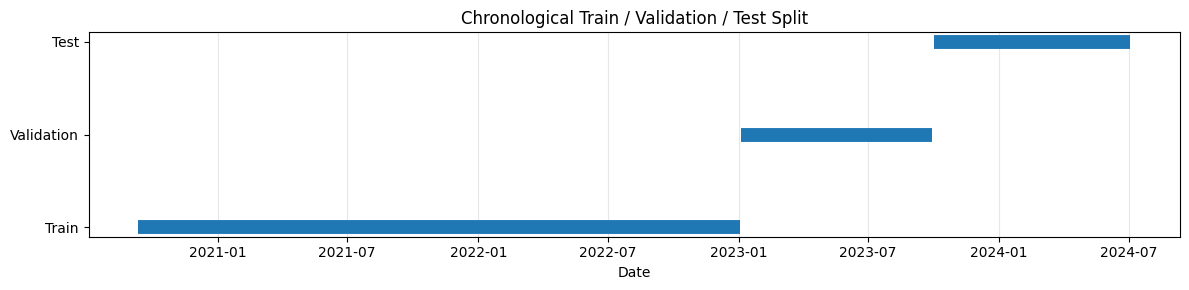

In [221]:
import matplotlib.pyplot as plt
import pandas as pd

split_ranges = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Start": [
        train_df["Datum"].min(),
        val_df["Datum"].min(),
        test_df["Datum"].min()
    ],
    "End": [
        train_df["Datum"].max(),
        val_df["Datum"].max(),
        test_df["Datum"].max()
    ]
})

plt.figure(figsize=(12, 3))

for i, row in split_ranges.iterrows():
    plt.hlines(
        y=row["Split"],
        xmin=row["Start"],
        xmax=row["End"],
        linewidth=10
    )

plt.xlabel("Date")
plt.title("Chronological Train / Validation / Test Split")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

#### Train model and  Hyperparameter tuning

###### Apply Random Forest

In [205]:
# =========================================================
# TRAIN PLAIN MODEL + TRAIN PREDICTIONS
# =========================================================
#read paper

base_rf = RandomForestRegressor(
    n_estimators=180,
    max_depth=None,
    min_samples_leaf=2,
    min_samples_split=4,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
base_rf.fit(X_train, y_train)



RandomForestRegressor(max_features='sqrt', min_samples_leaf=2,
                      min_samples_split=4, n_estimators=180, n_jobs=-1,
                      random_state=42)

In [206]:

train_pred_raw = base_rf.predict(X_train) # Predicts target fractions for the training features.
train_pred = postprocess_fraction_predictions(train_pred_raw) #Cleans the raw predictions so fraction values stay valid, for example non-negative and properly scaled if your function does that.
train_smape = smape_np(y_train, train_pred) #Calculates the overall training SMAPE.
train_per_fraction = smape_per_fraction_df(y_train, train_pred) #Calculates SMAPE separately for each fraction.

###### Model Tuning  + Time series CV

In [207]:
# =========================================================
# TIME SERIES CV + RANDOM SEARCH ON TRAINING DATA
# =========================================================

param_distributions = {
    "n_estimators": randint(100, 1000),
    "max_depth": [8, 12, 16, None],
    "min_samples_leaf": randint(1, 6),
    "min_samples_split": randint(2, 13),
    "max_features": ["sqrt", 0.35, 0.5],
    "bootstrap": [True],
}

tscv = TimeSeriesSplit(n_splits=N_SPLITS_CV)
search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=N_RANDOM_SEARCH_ITER,
    scoring=SMAPE_SCORER,
    cv=tscv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=0,
    return_train_score=True,
)
search.fit(X_train, y_train)

cv_results = pd.DataFrame(search.cv_results_)
cv_results["mean_cv_smape"] = -cv_results["mean_test_score"]
cv_cols = [
    "rank_test_score", "mean_cv_smape", "std_test_score", "mean_train_score",
    "param_n_estimators", "param_max_depth", "param_min_samples_leaf", "param_min_samples_split", "param_max_features"
]
##cv_results[cv_cols].sort_values("rank_test_score").to_csv(os.path.join(OUTPUT_DIR, "rf_random_search_cv_results.csv"), index=False)

best_params = search.best_params_
cv_best_smape = -search.best_score_
display(cv_results[cv_cols].sort_values("rank_test_score").head(5))

,rank_test_score,mean_cv_smape,std_test_score,mean_train_score,param_n_estimators,param_max_depth,param_min_samples_leaf,param_min_samples_split,param_max_features
0,1,0.315703,0.019098,-0.272906,800,16,3,9,sqrt
1,2,0.317034,0.017206,-0.264834,314,8,2,4,0.5
2,3,0.317853,0.020720,-0.275657,971,16,5,5,0.5
3,4,0.318084,0.021202,-0.275701,443,None,5,3,0.5


In [208]:
# =========================================================
# VALIDATION EVALUATION
# =========================================================

best_rf = search.best_estimator_

val_pred_raw = best_rf.predict(X_val)
val_pred = postprocess_fraction_predictions(val_pred_raw)
val_smape = smape_np(y_val, val_pred)
val_per_fraction = smape_per_fraction_df(y_val, val_pred).sort_values(by="SMAPE", ascending=True).reset_index(drop=True)

print("Validation SMAPE:", val_smape)
print("Validation SMAPE per fraction:")
display(val_per_fraction)

Validation SMAPE: 0.4022796973231357
Validation SMAPE per fraction:


,fraction,SMAPE
0,10,0.145915
1,5,0.147006
2,6,0.158094
3,3,0.168450
4,4,0.180526
5,1,0.199811
6,2,0.205067
7,7,0.232617
8,8,0.286902
9,9,0.317344


###### FINAL TEST MODEL: FIT TRAIN + VALIDATION, TEST ON HOLDOUT


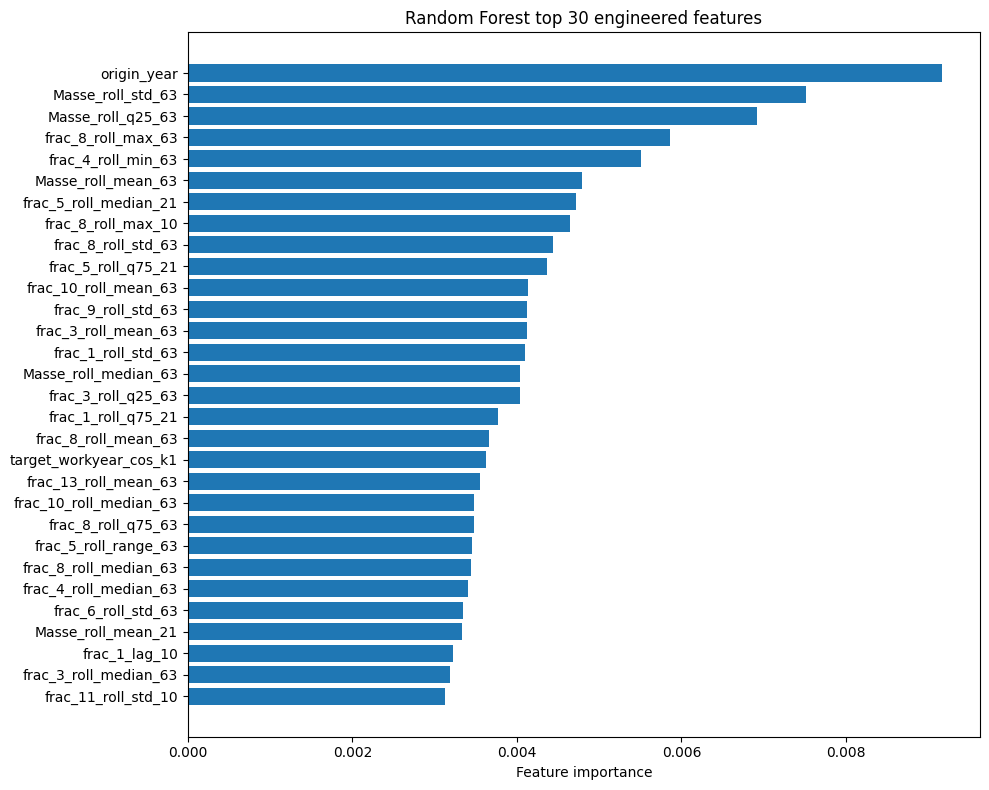

In [209]:

X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = np.vstack([y_train, y_val])

final_rf = RandomForestRegressor(**best_params, random_state=RANDOM_STATE, n_jobs=-1)
final_rf.fit(X_train_val, y_train_val)


# Feature importance
fi = pd.DataFrame({
    "feature": feature_cols,
    "importance": final_rf.feature_importances_
}).sort_values("importance", ascending=False)

# Plot feature importance top 30
plt.figure(figsize=(10, 8))
top = fi.head(30).iloc[::-1]
plt.barh(top["feature"], top["importance"])
plt.xlabel("Feature importance")
plt.title("Random Forest top 30 engineered features")
plt.tight_layout()
#plt.savefig(os.path.join(OUTPUT_DIR, "rf_top30_feature_importance_after_tuning.png"), dpi=200)
plt.show()

In [210]:
test_pred_raw = final_rf.predict(X_test)
test_pred = postprocess_fraction_predictions(test_pred_raw)
test_smape = smape_np(y_test, test_pred)
test_per_fraction = smape_per_fraction_df(y_test, test_pred)
# Sort by SMAPE in ascending order
test_per_fraction = test_per_fraction.sort_values( by="SMAPE", ascending=True).reset_index(drop=True)

print("Test SMAPE:", test_smape)
print("Test SMAPE per fraction:")
display(test_per_fraction)

Test SMAPE: 0.3954009866487903
Test SMAPE per fraction:


,fraction,SMAPE
0,5,0.105251
1,10,0.118648
2,2,0.120100
3,8,0.154774
4,3,0.159883
5,4,0.163279
6,6,0.174864
7,1,0.182445
8,9,0.199725
9,7,0.285324


In [211]:
train_smape

np.float64(0.23033706881043192)

In [212]:

# Train+validation fitted model predictions on train/val/test for traceability
train_final_pred = postprocess_fraction_predictions(final_rf.predict(X_train))
val_final_pred = postprocess_fraction_predictions(final_rf.predict(X_val))

# Save predictions wide
pred_rows = []
for split_name, split_df, y_true, y_hat in [("train", train_df, y_train, train_final_pred),("validation", val_df, y_val, val_pred),
 ("test", test_df, y_test, test_pred),]:
    for i in range(len(split_df)):
        row = {
            "split": split_name,
            "origin_date": split_df.iloc[i][DATE_COL],
            "target_date": split_df.iloc[i]["target_date"],
        }
        for j, col in enumerate(FRACTION_COLS):
            row[f"actual_{col}"] = y_true[i, j]
            row[f"pred_{col}"] = y_hat[i, j]
            row[f"smape_{col}"] = smape_np([y_true[i, j]], [y_hat[i, j]])
        row["row_mean_smape"] = np.mean([row[f"smape_{col}"] for col in FRACTION_COLS])
        pred_rows.append(row)

pred_df = pd.DataFrame(pred_rows)


# Summary
summary = pd.DataFrame([
    {"stage": "base_train_before_tuning", "SMAPE": train_smape},
    {"stage": "best_cv_on_train", "SMAPE": cv_best_smape},
    {"stage": "validation_after_tuning", "SMAPE": val_smape},
    {"stage": "test_after_refit_train_validation", "SMAPE": test_smape},
])

# Console output
print("DONE")
print("Supervised rows:", len(model_df))
print("Features:", len(feature_cols))
print("Best params:", best_params)
print("SMAPE summary:")
display(summary)



DONE
Supervised rows: 948
Features: 672
Best params: {'bootstrap': True, 'max_depth': 16, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 9, 'n_estimators': 800}
SMAPE summary:


,stage,SMAPE
0,base_train_before_tuning,0.230337
1,best_cv_on_train,0.315703
2,validation_after_tuning,0.402280
3,test_after_refit_train_validation,0.395401


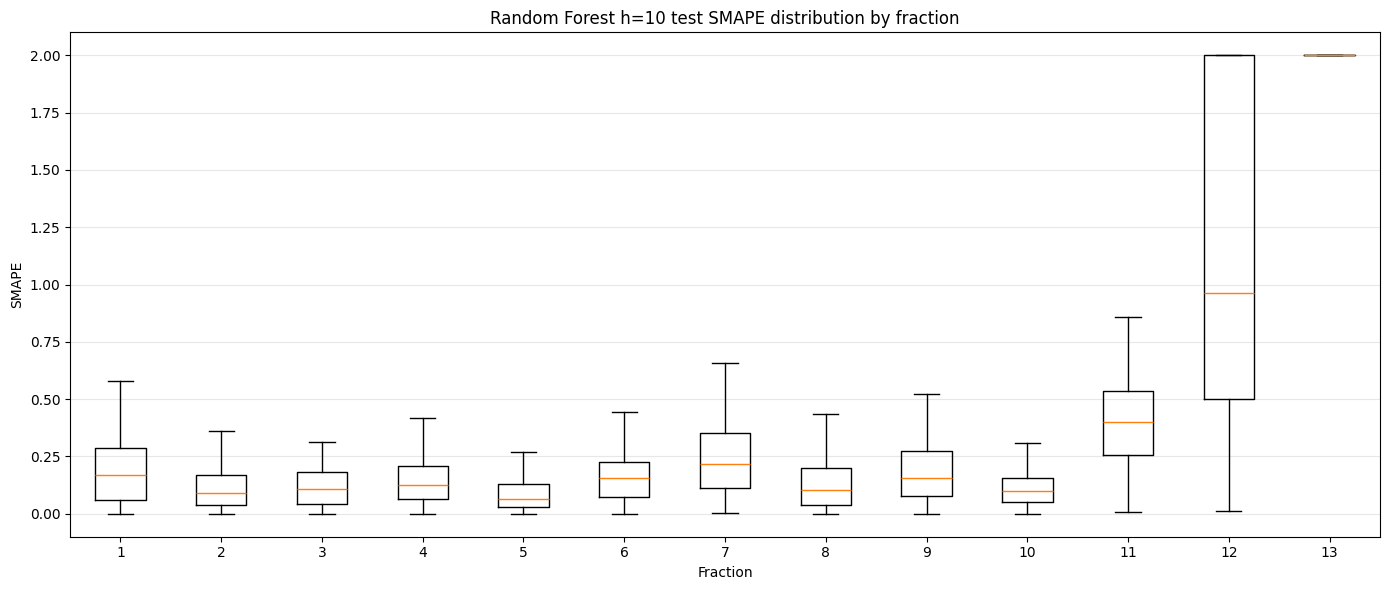

In [213]:
# Long error table for test boxplot
test_long_rows = []
for i in range(len(test_df)):
    for j, col in enumerate(FRACTION_COLS):
        test_long_rows.append({
            "origin_date": test_df.iloc[i][DATE_COL],
            "target_date": test_df.iloc[i]["target_date"],
            "fraction": col,
            "actual": y_test[i, j],
            "prediction": test_pred[i, j],
            "SMAPE": smape_np([y_test[i, j]], [test_pred[i, j]])
        })
test_error_long = pd.DataFrame(test_long_rows).sort_values(by="SMAPE", ascending= True)


# Plot boxplot by fraction
plt.figure(figsize=(14, 6))
box_data = [test_error_long[test_error_long["fraction"] == col]["SMAPE"].values for col in FRACTION_COLS]
plt.boxplot(box_data, labels=FRACTION_COLS, showfliers=False)
plt.xlabel("Fraction")
plt.ylabel("SMAPE")
plt.title("Random Forest h=10 test SMAPE distribution by fraction")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
#plt.savefig(os.path.join(OUTPUT_DIR, "rf_test_smape_boxplot_by_fraction_after_tuning.png"), dpi=200)
plt.show()


####comparison

In [214]:
# =========================================================
# MATERIAL / FRACTION SMAPE TABLE: VALIDATION VS TEST
# =========================================================
train_pf = train_per_fraction.copy()
val_pf = val_per_fraction.copy()
test_pf = test_per_fraction.copy()

train_pf= train_pf.rename(columns={"SMAPE": "Train_SMAPE"})
val_pf = val_pf.rename(columns={"SMAPE": "Validation_SMAPE"})
test_pf = test_pf.rename(columns={"SMAPE": "Test_SMAPE"})

material_baseline_table = val_pf.merge(
    test_pf,
    on="fraction",
    how="inner"
)

material_baseline_table = material_baseline_table.rename(
    columns={"fraction": "Material"}
)

# Sort by Test SMAPE: hardest materials first
material_baseline_table = (
    material_baseline_table
    .sort_values("Test_SMAPE", ascending=True)
    .reset_index(drop=True)
)

display(material_baseline_table)

,Material,Validation_SMAPE,Test_SMAPE
0,5,0.147006,0.105251
1,10,0.145915,0.118648
2,2,0.205067,0.120100
3,8,0.286902,0.154774
4,3,0.168450,0.159883
5,4,0.180526,0.163279
6,6,0.158094,0.174864
7,1,0.199811,0.182445
8,9,0.317344,0.199725
9,7,0.232617,0.285324


In [215]:
# =========================================================
# MANUAL BASELINE DATA
# =========================================================

baseline_pf_table = pd.DataFrame({
    "Material": [
        "13", "12", "11", "7", "8", "9", "2", "4",
        "3", "6", "1", "5", "10"
    ],

    "Baseline_Test_SMAPE_raw": [
        1.375677, 1.289747, 0.535250, 0.312874,
        0.310229, 0.287930, 0.221357, 0.220506,
        0.213842, 0.194780, 0.173680, 0.159562,
        0.148021
    ]
})
baseline_data = baseline_pf_table[["Material"]].copy()
#baseline_data["Baseline_Validation_SMAPE"] = (baseline_pf_table["Baseline_Validation_SMAPE_raw"] * 100)
baseline_data["Baseline_Test_SMAPE"] = ( baseline_pf_table["Baseline_Test_SMAPE_raw"])

display(baseline_data)

,Material,Baseline_Test_SMAPE
0,13,1.375677
1,12,1.289747
2,11,0.535250
3,7,0.312874
4,8,0.310229
5,9,0.287930
6,2,0.221357
7,4,0.220506
8,3,0.213842
9,6,0.194780


In [216]:
material_baseline_table= pd.DataFrame(material_baseline_table)
material_baseline_table_test = material_baseline_table[["Material", "Test_SMAPE"]].copy()

#display(material_baseline_table_test)


In [217]:
# =========================================================
# FINAL PER-FRACTION COMPARISON: BASELINE VS RF
# =========================================================

# Make sure Material column has same type everywhere
baseline_data["Material"] = baseline_data["Material"].astype(str)
material_baseline_table_test["Material"] = material_baseline_table_test["Material"].astype(str)

# Rename 'Test_SMAPE' to 'RF_Test_SMAPE' in material_baseline_table_test
material_baseline_table_test = material_baseline_table_test.rename(columns={"Test_SMAPE": "RF_Test_SMAPE"})


# Create one master comparison table
final_comparison_table = (
    baseline_data.merge(material_baseline_table_test, on="Material", how="inner")

)

# Find best model based on test SMAPE
test_cols = [ "Baseline_Test_SMAPE", "RF_Test_SMAPE"]

final_comparison_table["Best_Test_Model"] = ( final_comparison_table[test_cols].idxmin(axis=1) .str.replace("_Test_SMAPE", "", regex=False)
    .str.replace("RF", "Random Forest", regex=False)
)

final_comparison_table["Best_Test_SMAPE"] = final_comparison_table[test_cols].min(axis=1)

# Sort hardest materials first
final_comparison_table = (
    final_comparison_table
    .sort_values("Baseline_Test_SMAPE", ascending= False)
    .reset_index(drop=True)
)

display(final_comparison_table)

,Material,Baseline_Test_SMAPE,RF_Test_SMAPE,Best_Test_Model,Best_Test_SMAPE
0,13,1.375677,1.789444,Baseline,1.375677
1,12,1.289747,1.147953,Random Forest,1.147953
2,11,0.535250,0.538524,Baseline,0.535250
3,7,0.312874,0.285324,Random Forest,0.285324
4,8,0.310229,0.154774,Random Forest,0.154774
5,9,0.287930,0.199725,Random Forest,0.199725
6,2,0.221357,0.120100,Random Forest,0.120100
7,4,0.220506,0.163279,Random Forest,0.163279
8,3,0.213842,0.159883,Random Forest,0.159883
9,6,0.194780,0.174864,Random Forest,0.174864


In [218]:
final_comparison_table['SMAPE_Improvement'] = final_comparison_table['Baseline_Test_SMAPE'] - final_comparison_table['RF_Test_SMAPE']
final_comparison_table['Percentage_Improvement'] = (final_comparison_table['SMAPE_Improvement'] / final_comparison_table['Baseline_Test_SMAPE']) * 100

display(final_comparison_table[['Material', 'Baseline_Test_SMAPE', 'RF_Test_SMAPE', 'Best_Test_Model', 'Percentage_Improvement']].sort_values(by='Percentage_Improvement', ascending=False))

print(f"\nOverall, the Random Forest model showed an average SMAPE improvement of {final_comparison_table['SMAPE_Improvement'].mean():.4f} (approximately {final_comparison_table['Percentage_Improvement'].mean():.2f}%) compared to the Baseline model.")
print(f"The Random Forest model outperformed the Baseline in {final_comparison_table[final_comparison_table['SMAPE_Improvement'] > 0].shape[0]} out of {final_comparison_table.shape[0]} materials.")

,Material,Baseline_Test_SMAPE,RF_Test_SMAPE,Best_Test_Model,Percentage_Improvement
4,8,0.310229,0.154774,Random Forest,50.109901
6,2,0.221357,0.120100,Random Forest,45.743764
11,5,0.159562,0.105251,Random Forest,34.037828
5,9,0.287930,0.199725,Random Forest,30.634106
7,4,0.220506,0.163279,Random Forest,25.952807
8,3,0.213842,0.159883,Random Forest,25.232905
12,10,0.148021,0.118648,Random Forest,19.843978
1,12,1.289747,1.147953,Random Forest,10.993967
9,6,0.194780,0.174864,Random Forest,10.224648
3,7,0.312874,0.285324,Random Forest,8.805573



Overall, the Random Forest model showed an average SMAPE improvement of 0.0233 (approximately 17.37%) compared to the Baseline model.
The Random Forest model outperformed the Baseline in 10 out of 13 materials.


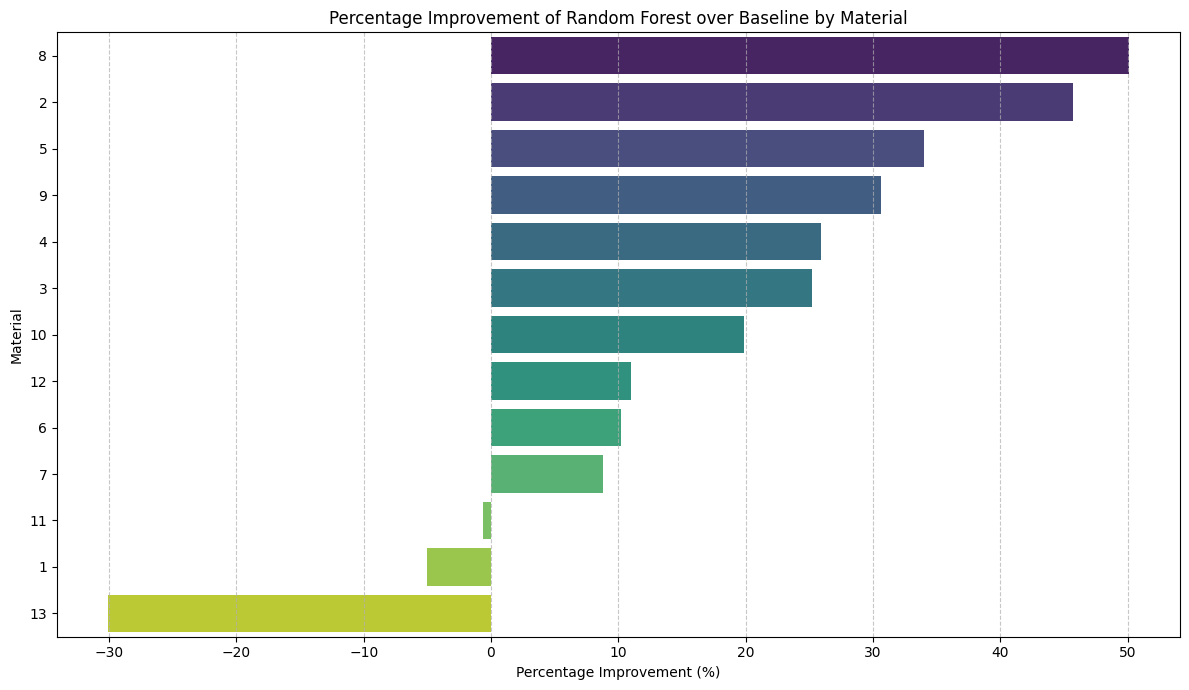

In [219]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the table by Percentage_Improvement for better visualization
final_comparison_table_sorted = final_comparison_table.sort_values(by='Percentage_Improvement', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Percentage_Improvement', y='Material', data=final_comparison_table_sorted, palette='viridis')
plt.xlabel('Percentage Improvement (%)')
plt.ylabel('Material')
plt.title('Percentage Improvement of Random Forest over Baseline by Material')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()